In [1]:
# Option B - Breast Cancer Classification with SVM
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import datasets
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

In [2]:
# Load dataset
cancer_data = datasets.load_breast_cancer()
X = cancer_data.data  # Features
y = cancer_data.target  # Labels (0 = benign, 1 = malignant)

In [3]:
# Split data into training (80%) and testing (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [4]:
# Standardizing features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [5]:
# SVM Classifier with Hyperparameter Tuning using GridSearchCV
param = {'C': [0.1, 1, 10], 'kernel': ['linear', 'rbf']}
grid = GridSearchCV(SVC(), param, cv=5, scoring='accuracy')
grid.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=SVC(),
             param_grid={'C': [0.1, 1, 10], 'kernel': ['linear', 'rbf']},
             scoring='accuracy')

In [6]:
# Best Model Selection
best_svm = grid.best_estimator_

# Model Evaluation on Test Set
y_pred = best_svm.predict(X_test)

In [11]:
from sklearn.metrics import classification_report

# Print classification report for both classes
report = classification_report(y_test, y_pred, target_names=["Benign", "Malignant"])
print(report)

              precision    recall  f1-score   support

      Benign       1.00      0.95      0.98        43
   Malignant       0.97      1.00      0.99        71

    accuracy                           0.98       114
   macro avg       0.99      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



In [15]:
# Performance Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# Cross-validation accuracy
cv = cross_val_score(best_svm, X_train, y_train, cv=5)

In [17]:
# Output Results
print("Best SVM Model Performance:")
print(f"Accuracy: {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1-score: {f1:.2f}")
print(f"Cross-validation accuracy: {cv.mean():.2f}")

Best SVM Model Performance:
Accuracy: 0.98
Precision: 0.97
Recall: 1.00
F1-score: 0.99
Cross-validation accuracy: 0.98


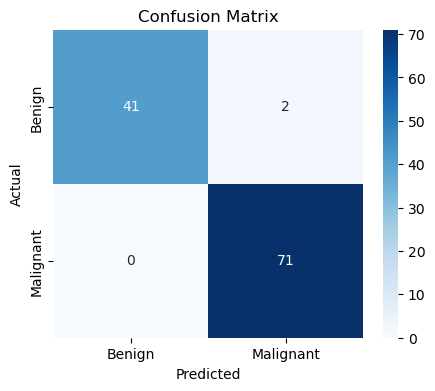

In [19]:
# Confusion Matrix Visualization
plt.figure(figsize=(5, 4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues', xticklabels=['Benign', 'Malignant'], yticklabels=['Benign', 'Malignant'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

https://github.com/ShubhGTiwari/AI_healhcare_assignment